# Target Visibility Checker
- **Cell 1** — imports and helper functions.
- **Cell 2** — everything you edit: `targets_list`, the UTC start/stop, the
  cadence in minutes, and the `Visibility` instance (default keep-outs).
- **Cell 3** — per-target visibility from `get_visibility_best_roll`, with a
  statistics summary.
- **Cell 4** — one timeline for all targets: a green line wherever the target
  is visible.
- **Cell 5** — per-target breakdown of which constraint is failing while the
  target is not visible.

In [1]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.coordinates.name_resolve import sesame_database
from astropy.time import Time, TimeDelta

from pandoravisibility import Visibility, find_continuous_periods

# Resolve target names against SIMBAD specifically, not the default mirror list.
sesame_database.set("simbad")

_resolved_names = {}


def resolve_target(target):
    """
    Turn one ``targets_list`` entry into a name and a sky coordinate.

    Parameters
    ----------
    target : str or tuple
        One of: a name to look up in SIMBAD (``"WASP-50"``), a pair of
        decimal degrees (``(258.831, 4.96068)``), or a pair of sexagesimal
        strings (``("21h44m10.6s", "-05d05m41s")``).

    Returns
    -------
    name : str or None
        The name as supplied, or None when coordinates were given directly.
    coord : astropy.coordinates.SkyCoord
        ICRS coordinate of the target.
    """
    if isinstance(target, str):
        if target not in _resolved_names:
            _resolved_names[target] = SkyCoord.from_name(target)
        return target, _resolved_names[target]

    right_ascension, declination = target
    if isinstance(right_ascension, str):
        coord = SkyCoord(
            right_ascension, declination,
            frame="icrs", unit=(u.hourangle, u.deg),
        )
    else:
        coord = SkyCoord(right_ascension, declination, frame="icrs", unit=u.deg)
    return None, coord


def target_label(name, coord):
    """
    Short plot label: the name if there is one, else RA/Dec in degrees.

    Parameters
    ----------
    name : str or None
        Target name, or None.
    coord : astropy.coordinates.SkyCoord
        Target coordinate, used when *name* is None.

    Returns
    -------
    str
        Either the name, or ``"RA, Dec"`` to three decimal places.
    """
    if name is not None:
        return name
    return f"{coord.ra.deg:.3f}, {coord.dec.deg:+.3f}"


def build_time_grid(start_utc, stop_utc, step_minutes):
    """
    Regular UTC time grid covering [start_utc, stop_utc).

    Parameters
    ----------
    start_utc, stop_utc : str
        ISO UTC timestamps, e.g. ``"2026-05-05T00:00:00"``.
    step_minutes : float
        Spacing between time steps, in minutes.

    Returns
    -------
    astropy.time.Time
        Array of observation times.
    """
    start = Time(start_utc, scale="utc")
    stop = Time(stop_utc, scale="utc")
    if stop <= start:
        raise ValueError("stop_utc must be later than start_utc")
    span_minutes = (stop - start).to_value(u.min)
    return start + TimeDelta(np.arange(0.0, span_minutes, step_minutes) * u.min)


def run_stats(times, mask, step_minutes):
    """
    Count contiguous True runs in *mask* and measure the longest.

    Parameters
    ----------
    times : astropy.time.Time
        Time grid matching *mask*.
    mask : array_like of bool
        Per-timestep flags, typically a visibility result.
    step_minutes : float
        Grid spacing, used to give the final step of a run its dwell time.

    Returns
    -------
    n_runs : int
        Number of contiguous runs.
    longest_minutes : float
        Duration of the longest run, in minutes.
    """
    periods = find_continuous_periods(times, np.asarray(mask, dtype=bool), 0.0)
    if not periods:
        return 0, 0.0
    longest = max(period["duration_hours"] for period in periods) * 60.0
    return len(periods), longest + step_minutes


def mask_segments(times, mask, step_minutes):
    """
    Contiguous True runs of *mask* as (start, width) pairs for ``broken_barh``.

    Parameters
    ----------
    times : astropy.time.Time
        Time grid matching *mask*.
    mask : array_like of bool
        Per-timestep flags to draw.
    step_minutes : float
        Grid spacing.  Each run is padded by one step so that a single
        isolated timestep still draws a visible bar.

    Returns
    -------
    list of tuple
        ``(start, width)`` pairs in matplotlib date units.
    """
    time_numbers = mdates.date2num(times.to_datetime())
    step_width = step_minutes / (24.0 * 60.0)
    segments = []
    for period in find_continuous_periods(times, np.asarray(mask, dtype=bool), 0.0):
        start = time_numbers[period["start_index"]]
        stop = time_numbers[period["end_index"]]
        segments.append((start, stop - start + step_width))
    return segments


#: Thickness of one timeline row, in y-axis units.
BAR_HEIGHT = 0.18


def draw_row(ax, row, segments, color):
    """
    Draw one row of horizontal bars centred on integer position *row*.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to draw on.
    row : int
        Row index, matching the order of the y tick labels.
    segments : list of tuple
        ``(start, width)`` pairs from :func:`mask_segments`.
    color : str
        Any matplotlib colour specification.
    """
    ax.broken_barh(segments, (row - BAR_HEIGHT / 2, BAR_HEIGHT), facecolors=color)


def format_date_axis(ax, times):
    """
    Put a concise UTC scale on the x-axis and clip it to the time grid.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes to format.
    times : astropy.time.Time
        Time grid defining the axis limits.
    """
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    time_numbers = mdates.date2num(times.to_datetime())
    ax.set_xlim(time_numbers[0], time_numbers[-1])
    ax.set_xlabel("UTC")


def label_rows(ax, labels):
    """
    Label one horizontal bar row per entry in *labels*, top to bottom.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes holding the bar rows.
    labels : sequence of str
        Row labels, in the order the rows were drawn.
    """
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_ylim(len(labels) - 0.5, -0.5)
    ax.grid(axis="x", alpha=0.3)

## Edit this cell

`targets_list` accepts names (looked up in SIMBAD), decimal-degree pairs, and
sexagesimal string pairs — mix them freely.

In [2]:
# Targets
# targets_list = [
#     "GJ 1214",                       # name → looked up in SIMBAD
#     "WASP-80",
#     "TOI-836",
#     "KELT-9",                        # inside the Sun keep-out all day here
#     (255.0, 10.0),                   # RA, Dec in decimal degrees
#     ("17h00m00s", "-30d00m00s"),     # RA, Dec as sexagesimal strings
# ]

targets_list = [
    "HD209458",
    "WASP-69",
    "KELT-9",
    "HAT-P-67",
    "GJ 12",
    "K2-141",
    "KELT-20",
    "GJ 9827",
    "HD221416",
    "TOI-1533",
    "WASP-52"
]

# Time window (UTC) and cadence
start_utc = "2026-08-10T00:00:00"
stop_utc = "2026-08-24T00:00:00"
time_step_minutes = 10.0

# Spacecraft orbit
# Draft TLE for Pandora — use the most up-to-date one for real work!
line1 = "1 67395U 80229J   26212.76861111  .00000000  00000-0  37770-3 0    05"
line2 = "2 67395  97.8073 210.7389 0004787   3.5990  91.5851 14.88172851    02"

# Default keep-outs: Sun ≥ 91°, Moon ≥ 25°, Earth limb ≥ 20°, no star
# tracker limits.  Pass overrides here to tighten anything, e.g.
# Visibility(line1, line2, earthlimb_day_min=45*u.deg, st_sun_min=44*u.deg).
visibility = Visibility(
    line1, line2,
    earthlimb_day_min=44 * u.deg,
    earthlimb_night_min=13 * u.deg,
    sun_min=91 * u.deg,
    moon_min=20 * u.deg,
    st_sun_min=50 * u.deg,
    st_moon_min=20 * u.deg,
    st_earthlimb_min=30 * u.deg,
    st_required=1
)

# Roll sweep settings for get_visibility_best_roll.  These only bite once
# star tracker keep-outs are active, which the defaults leave switched off.
roll_step = 2 * u.deg
orbit_time_step = 1 * u.min

times = build_time_grid(start_utc, stop_utc, time_step_minutes)

print(visibility)
print(f"Orbital period: {visibility.get_period():.2f}")
print(f"{len(times)} steps of {time_step_minutes:g} min: "
      f"{times[0].iso} → {times[-1].iso}")

<Visibility: SAT67395 [moon≥20 deg, sun≥91 deg, limb_day≥44 deg, limb_night≥13 deg, st_sun≥50 deg, st_moon≥20 deg, st_limb≥30 deg, st_req=1]>
Orbital period: 96.76 min
2016 steps of 10 min: 2026-08-10 00:00:00.000 → 2026-08-23 23:50:00.000


## Visibility per target

`get_visibility_best_roll` picks the best fixed roll angle for each orbit and
reports visibility at every time step.  With the default keep-outs there are no
star tracker constraints, so `visible` and `boresight_visible` agree and no roll
angle is selected.

In [3]:
results = {}

header = (
    f"{'Target':<24}{'Visible':>13}{'Duty':>8}{'Windows':>9}{'Longest':>10}"
)
print(header)
print("-" * len(header))

for target in targets_list:
    name, coord = resolve_target(target)
    label = target_label(name, coord)

    best_roll = visibility.get_visibility_best_roll(
        coord, times, roll_step=roll_step, orbit_time_step=orbit_time_step,
    )
    visible = np.asarray(best_roll["visible"])
    n_windows, longest_minutes = run_stats(times, visible, time_step_minutes)

    results[label] = {"coord": coord, "visible": visible, "best_roll": best_roll}

    print(
        f"{label:<24}"
        f"{f'{visible.sum()} / {len(times)}':>13}"
        f"{100 * visible.mean():>7.1f}%"
        f"{n_windows:>9}"
        f"{longest_minutes:>8.0f} m"
    )

roll_used = np.concatenate([r["best_roll"]["roll_deg"].ravel() for r in results.values()])
if np.isfinite(roll_used).any():
    print(f"\nMedian roll angle used: {np.nanmedian(roll_used):.1f} deg")
else:
    print("\nNo roll angle selected (no star tracker constraints active).")

Target                        Visible    Duty  Windows   Longest
----------------------------------------------------------------
HD209458                   682 / 2016   33.8%      209      40 m
WASP-69                   1004 / 2016   49.8%      209      50 m
KELT-9                     629 / 2016   31.2%      328      40 m
HAT-P-67                   574 / 2016   28.5%      208      30 m
GJ 12                      903 / 2016   44.8%      209      50 m
K2-141                     912 / 2016   45.2%      209      50 m
KELT-20                    605 / 2016   30.0%      355      40 m
GJ 9827                    911 / 2016   45.2%      209      50 m
HD221416                   960 / 2016   47.6%      209      50 m
TOI-1533                   663 / 2016   32.9%      209      40 m
WASP-52                    892 / 2016   44.2%      209      50 m

Median roll angle used: -68.0 deg


## When is each target visible?

A green line means the target clears every constraint at that time step.

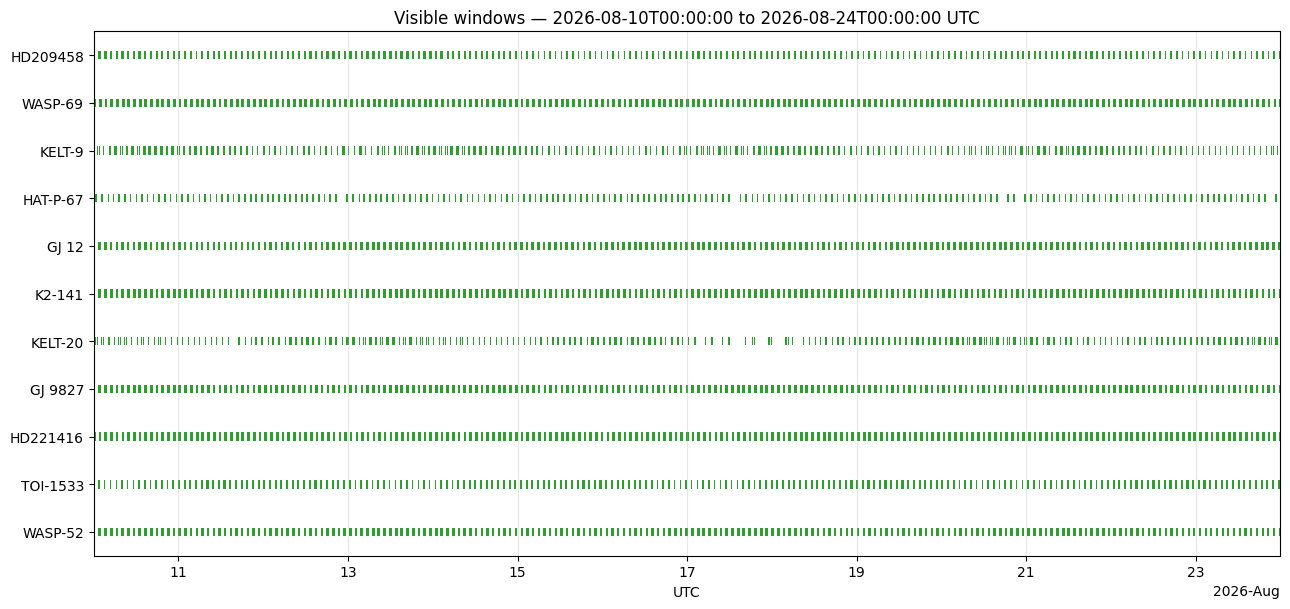

In [4]:
fig, ax = plt.subplots(figsize=(13, 0.4 * len(results) + 1.8))

for row, result in enumerate(results.values()):
    draw_row(
        ax, row,
        mask_segments(times, result["visible"], time_step_minutes),
        "tab:green",
    )

label_rows(ax, list(results))
format_date_axis(ax, times)
ax.set_title(f"Visible windows — {start_utc} to {stop_utc} UTC")
plt.tight_layout()

## Which constraint is failing?

For each target, a red bar marks the time steps where that individual
constraint fails; the grey row at the bottom is the overall "not visible"
result for comparison.

`get_all_constraints` evaluates each body through the astropy code path, while
`get_visibility_best_roll` uses the faster vector path.  The two can disagree
on a time step sitting exactly on a threshold, so the printout also counts any
not-visible steps that no individual constraint explains.

In [ ]:
for label, result in results.items():
    constraints = visibility.get_all_constraints(result["coord"], times)
    failures = {
        name: ~np.asarray(passed) for name, passed in constraints.items()
    }
    not_visible = ~result["visible"]

    explained = np.zeros_like(not_visible)
    for fail_mask in failures.values():
        explained |= fail_mask
    unexplained = int(np.sum(not_visible & ~explained))

    rows = list(failures) + ["not visible"]
    fig, ax = plt.subplots(figsize=(13, 0.4 * len(rows) + 1.8))
    for row, name in enumerate(failures):
        draw_row(
            ax, row,
            mask_segments(times, failures[name], time_step_minutes),
            "tab:red",
        )
    draw_row(
        ax, len(rows) - 1,
        mask_segments(times, not_visible, time_step_minutes),
        "0.5",
    )

    label_rows(ax, rows)
    format_date_axis(ax, times)
    ax.set_title(f"{label} — failing constraints")
    plt.tight_layout()

    print(f"{label}: not visible at {int(not_visible.sum())} of {len(times)} steps")
    for name, fail_mask in failures.items():
        print(f"    {name:<12} fails at {int(fail_mask.sum()):>5} steps")
    if unexplained:
        print(f"    {unexplained} not-visible steps not explained by the above")

HD209458: not visible at 1334 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at  1332 steps
    star_tracker fails at   651 steps
    2 not-visible steps not explained by the above
WASP-69: not visible at 1012 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at  1012 steps
    star_tracker fails at   555 steps
KELT-9: not visible at 1387 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at  1212 steps
    star_tracker fails at   559 steps
    43 not-visible steps not explained by the above
HAT-P-67: not visible at 1442 of 2016 steps
    moon         fails at     0 steps
    sun          fails at     0 steps
    earthlimb    fails at  1088 steps
    star_tracker fails at   463 steps
    113 not-visible steps not explained by the above
GJ 12: not visible at 1113 of 2016 steps
    moon         fails